In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("data/egx/EAST.csv")
df.columns = df.columns.str.strip()
date_col = next(col for col in df.columns if col.lower() == "date")
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)
df.set_index(date_col, inplace=True)
df.head()

,open,high,low,close,volume
date,,,,,
2015-01-04,4.865777,4.888888,4.611111,4.888222,1913490
2015-01-05,4.888222,5.111111,4.888888,5.016222,2162295
2015-01-06,5.016222,5.111111,5.109777,5.110888,4621635
2015-01-08,5.110888,5.222222,5.111111,5.188000,6870195
2015-01-11,5.188000,5.222222,5.188000,5.221777,686745


In [24]:
df.columns = df.columns.str.strip()
close_col = next(
    col for col in df.columns
    if col.lower() in ["close", "adj close", "last", "price", "closing price"]
)
df["MA9"] = df[close_col].rolling(window=9).mean()
df["MA20"] = df[close_col].rolling(window=20).mean()
df.head()
df.tail()

,open,high,low,close,volume,MA9,MA20
date,,,,,,,
2026-07-26,37.490002,37.580002,36.820000,36.820000,373200,36.825556,37.1495
2026-07-27,36.820000,37.070000,36.110001,36.369999,1509024,36.814445,37.0430
2026-07-28,36.369999,36.459999,36.009998,36.150002,710269,36.793334,36.9460
2026-07-29,36.150002,36.799999,36.099998,36.759998,9683447,36.852222,36.9340
2026-07-30,36.759998,36.689999,36.099998,36.400002,1914080,36.796667,36.8790


In [25]:
initial_cash = 1000
cash = initial_cash
shares = 0
portfolio_values = []
buy_points = []
sell_points = []
buy_count = 0
sell_count = 0
for i in range(len(df)):

    price = df[close_col].iloc[i]

    if np.isnan(df["MA9"].iloc[i]) or np.isnan(df["MA20"].iloc[i]):
        portfolio_values.append(cash)
        continue

    if df["MA9"].iloc[i] > df["MA20"].iloc[i] and shares == 0:
        shares = cash / price
        cash = 0

        buy_points.append(i)
        buy_count += 1

    elif df["MA9"].iloc[i] < df["MA20"].iloc[i] and shares > 0:
        cash = shares * price
        shares = 0

        sell_points.append(i)
        sell_count += 1

    if shares > 0:
        value = shares * price
    else:
        value = cash

    portfolio_values.append(value)

In [26]:
if shares > 0:
    final_portfolio = shares * df["Close"].iloc[-1]
else:
    final_portfolio = cash

print(f"Final Portfolio Value: {final_portfolio:.2f} EGP")

Final Portfolio Value: 3532.73 EGP


In [27]:
portfolio = pd.Series(portfolio_values, index=df.index)
running_max = portfolio.cummax()
drawdown = (portfolio - running_max) / running_max
max_drawdown = drawdown.min()
print(f"Maximum Drawdown: {max_drawdown*100:.2f}%")

Maximum Drawdown: -71.22%


In [28]:
print("Buy Operations :", buy_count)
print("Sell Operations:", sell_count)

Buy Operations : 77
Sell Operations: 77


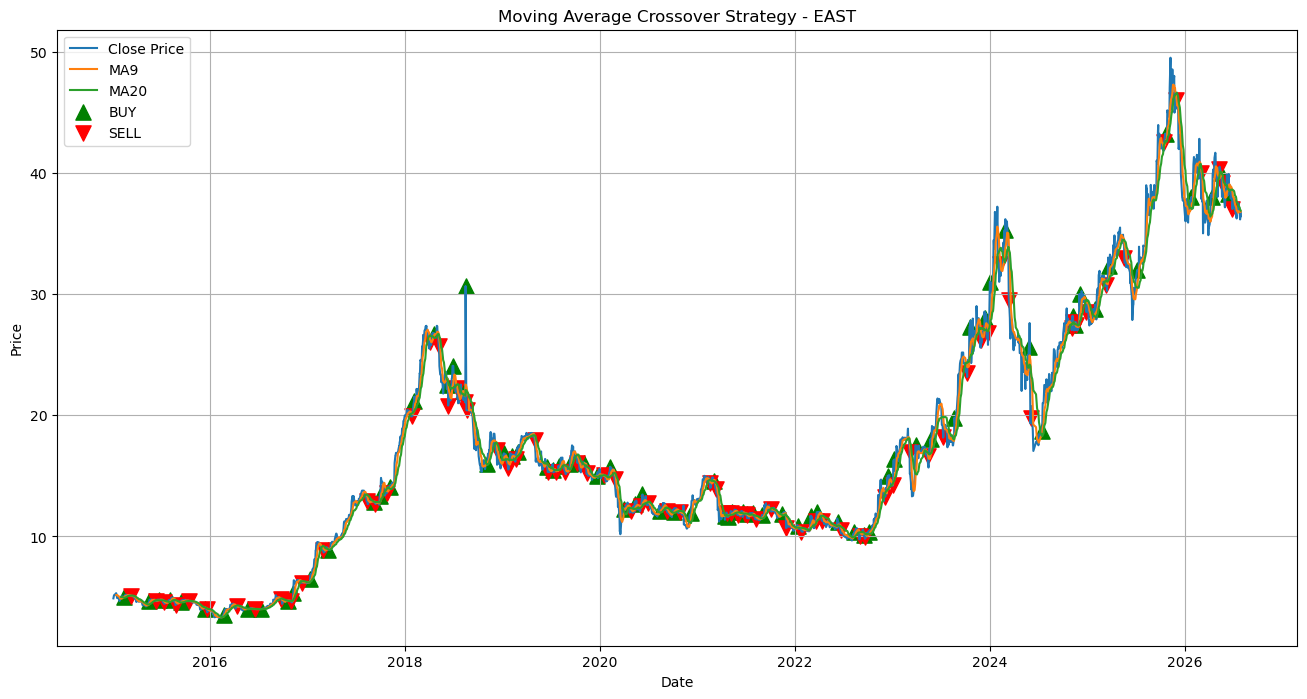

In [29]:
plt.figure(figsize=(16,8))

plt.plot(df.index, df[close_col], label="Close Price")
plt.plot(df.index, df["MA9"], label="MA9")
plt.plot(df.index, df["MA20"], label="MA20")

plt.scatter(
    df.index[buy_points],
    df[close_col].iloc[buy_points],
    marker="^",
    color="green",
    s=120,
    label="BUY"
)

plt.scatter(
    df.index[sell_points],
    df[close_col].iloc[sell_points],
    marker="v",
    color="red",
    s=120,
    label="SELL"
)

plt.title("Moving Average Crossover Strategy - EAST")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

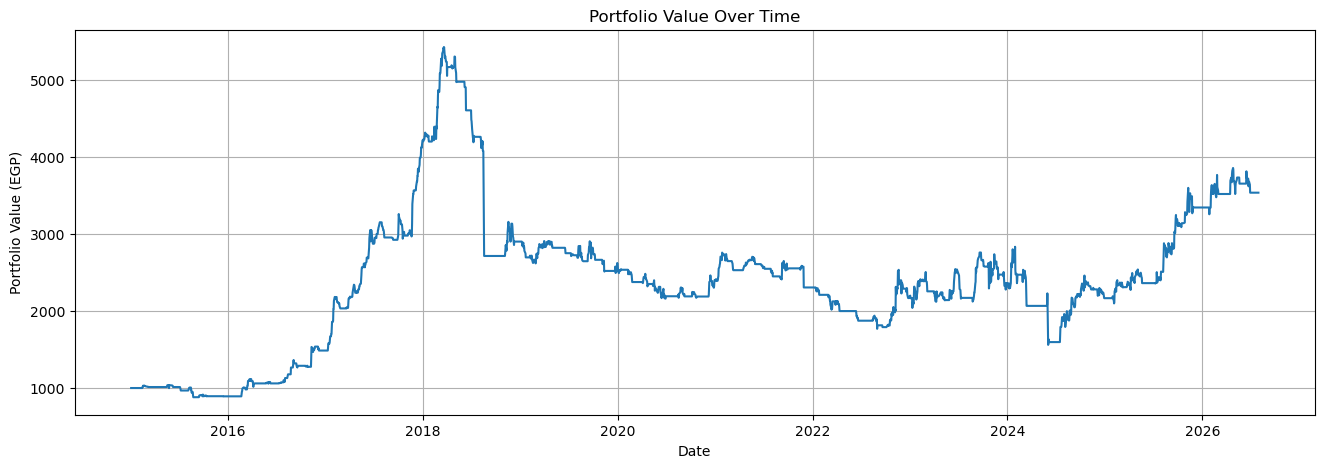

In [30]:
plt.figure(figsize=(16,5))

plt.plot(df.index, portfolio_values)

plt.title("Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (EGP)")
plt.grid(True)

plt.show()